# TP3 : Compression d'images par apprentissage profond de bout en bout
**Codage et sécurisation des données visuelles** — ISI, 2025-2026

On teste des codeurs d'images **pré-entraînés** de la bibliothèque CompressAI (auto-encodeurs variationnels) :
- `mbt2018` (qualité 4) ;
- `bmshj2018-factorized`, `bmshj2018-hyperprior` et `mbt2018-mean` pour la qualité `q = 1 … 8`.

Pour chaque modèle on mesure le **débit** (bpp) et le **PSNR** (dB), puis on trace les courbes débit-distorsion.

**Notes pratiques**
- On ne fait que de l'**inférence** (modèles pré-entraînés). Tout s'exécute sur **CPU**, aucun GPU n'est nécessaire.
- Les poids pré-entraînés sont **téléchargés automatiquement** au premier appel de `pretrained=True` (connexion Internet nécessaire), puis mis en cache.
- Sous Linux, pas besoin de *Microsoft C++ Build Tools* : ils servent uniquement à compiler CompressAI sous Windows, et c'est déjà installé dans `multimedia312`.
- Le polycopié utilise `%run codec.py` (ligne de commande) pour hyperprior et mean. Ici on utilise l'API Python pour les trois modèles, ce qui est plus simple et donne exactement les mêmes mesures.

## 0. Imports et configuration

In [1]:
import os
import time
import urllib.request

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn.functional as F
import torchvision
from torchvision.io import read_image, ImageReadMode

from compressai.zoo import (
    bmshj2018_factorized,
    bmshj2018_hyperprior,
    mbt2018_mean,
    mbt2018,
)

DATA_DIR = "."                 # kodim05.png ici
OUT_DIR = "resultats_tp3"
os.makedirs(OUT_DIR, exist_ok=True)

IMAGE_NAME = "kodim05.png"
QUALITIES = list(range(1, 9))  # q = 1..8

# CPU partout : les modèles à contexte autorégressif (mbt2018) ne fonctionnent
# de toute façon que sur CPU pour compress()/decompress().
device = "cpu"
torch.set_num_threads(max(1, os.cpu_count() or 1))

print("PyTorch     :", torch.__version__)
print("TorchVision :", torchvision.__version__)
print("Device      :", device)

/home/primaryos/anaconda3/envs/multimedia312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch     : 2.5.1+cu124
TorchVision : 0.20.1+cu124
Device      : cpu


In [2]:
KODAK_URL = "https://r0k.us/graphics/kodak/kodak/{}"

path = os.path.join(DATA_DIR, IMAGE_NAME)
if os.path.exists(path):
    print(f"OK         : {IMAGE_NAME} déjà présent")
else:
    try:
        urllib.request.urlretrieve(KODAK_URL.format(IMAGE_NAME), path)
        print(f"Téléchargé : {IMAGE_NAME}")
    except Exception as e:
        print(f"ECHEC : {e} -> copiez {IMAGE_NAME} dans {os.path.abspath(DATA_DIR)}")

OK         : kodim05.png déjà présent


## Fonctions utilitaires

In [3]:
def charger_image(chemin):
    # Image -> tenseur float32 (1, 3, H, W) dans [0, 1]
    t8 = read_image(chemin, mode=ImageReadMode.RGB)    # uint8 (3, H, W)
    return (t8.to(torch.float32) / 255.0).unsqueeze(0)

def pad_multiple(x, p=64):
    # Les modèles exigent des dimensions multiples de 64 (Kodak : déjà le cas).
    _, _, h, w = x.shape
    new_h = (h + p - 1) // p * p
    new_w = (w + p - 1) // p * p
    pl = (new_w - w) // 2
    pr = new_w - w - pl
    pt = (new_h - h) // 2
    pb = new_h - h - pt
    return F.pad(x, (pl, pr, pt, pb), mode="constant", value=0), (pl, pr, pt, pb)

def crop(x, pads):
    pl, pr, pt, pb = pads
    return F.pad(x, (-pl, -pr, -pt, -pb))

def taille_flux_bits(out_enc):
    # out_enc["strings"] est une liste de listes d'octets :
    #   factorized -> [[y]]   |   hyperprior / mean / mbt2018 -> [[y], [z]]
    # On additionne TOUS les flux (y et z), sinon le débit est sous-estimé.
    return sum(len(s) for lst in out_enc["strings"] for s in lst) * 8

def psnr_torch(a, b):
    mse = torch.mean((a - b) ** 2)
    if mse.item() == 0:
        return float("inf")
    return (10 * torch.log10(1.0 / mse)).item()

def tensor_vers_image(t):
    # Tenseur (1, 3, H, W) dans [0, 1] -> image PIL RGB
    arr = (t[0].clamp(0, 1) * 255).round().permute(1, 2, 0).cpu().numpy().astype(np.uint8)
    return Image.fromarray(arr)

def compresser_decompresser(model, x):
    # Encode + décode x (1,3,H,W) ; renvoie l'image reconstruite et les mesures.
    H, W = x.shape[2], x.shape[3]
    x_pad, pads = pad_multiple(x)

    with torch.no_grad():
        t0 = time.time()
        out_enc = model.compress(x_pad)                                    # Encodage
        t_enc = time.time() - t0

        t0 = time.time()
        out_dec = model.decompress(out_enc["strings"], out_enc["shape"])   # Décodage
        t_dec = time.time() - t0

    rec = crop(out_dec["x_hat"], pads).clamp(0, 1)
    rec = (rec * 255).round() / 255          # quantification 8 bits (comme l'image sauvegardée)

    bpp = taille_flux_bits(out_enc) / (H * W)
    psnr = psnr_torch(x, rec)
    return rec, bpp, psnr, t_enc, t_dec

## II. Compression des images par différents modèles
### 1. Compression par le modèle mbt2018 (qualité 4)
Étapes du polycopié : chargement de l'image, conversion en float [0, 1], ajout de la dimension batch, compression, décompression, conversion en image, sauvegarde.

In [4]:
# 1-3. Chargement, normalisation [0, 1], dimension batch
img_tensor_batch = charger_image(os.path.join(DATA_DIR, IMAGE_NAME)).to(device)

print("Final tensor shape:", img_tensor_batch.shape)
print("Final tensor dtype:", img_tensor_batch.dtype)
print("Min pixel value   :", img_tensor_batch.min().item())
print("Max pixel value   :", img_tensor_batch.max().item())

H, W = img_tensor_batch.shape[2], img_tensor_batch.shape[3]

Final tensor shape: torch.Size([1, 3, 512, 768])
Final tensor dtype: torch.float32
Min pixel value   : 0.0
Max pixel value   : 1.0


In [5]:
# Chargement du modèle pré-entraîné (téléchargement des poids au premier appel)
model = mbt2018(quality=4, pretrained=True).eval().to(device)
print("Modèle mbt2018 chargé avec succès.")

Downloading: "https://compressai.s3.amazonaws.com/models/v1/mbt2018-4-456e2af9.pth.tar" to /home/primaryos/.cache/torch/hub/checkpoints/mbt2018-4-456e2af9.pth.tar
100%|██████████| 61.8M/61.8M [01:26<00:00, 746kB/s] 


Modèle mbt2018 chargé avec succès.


In [6]:
# 4. Compression + décompression (mbt2018 est autorégressif : lent sur CPU)
rec_mbt, bpp_mbt, psnr_mbt, t_enc, t_dec = compresser_decompresser(model, img_tensor_batch)

print(f"mbt2018, q=4 -> Bitrate = {bpp_mbt:.4f} bpp - PSNR = {psnr_mbt:.2f} dB")
print(f"Temps : encodage {t_enc:.1f} s, décodage {t_dec:.1f} s")

# 5-6. Conversion tenseur -> image et sauvegarde
image_mbt = tensor_vers_image(rec_mbt)
image_mbt.save(os.path.join(OUT_DIR, "reconstructed_image.png"))
print("Compression + reconstruction terminées.")

mbt2018, q=4 -> Bitrate = 0.7655 bpp - PSNR = 31.40 dB
Temps : encodage 3.4 s, décodage 9.6 s
Compression + reconstruction terminées.


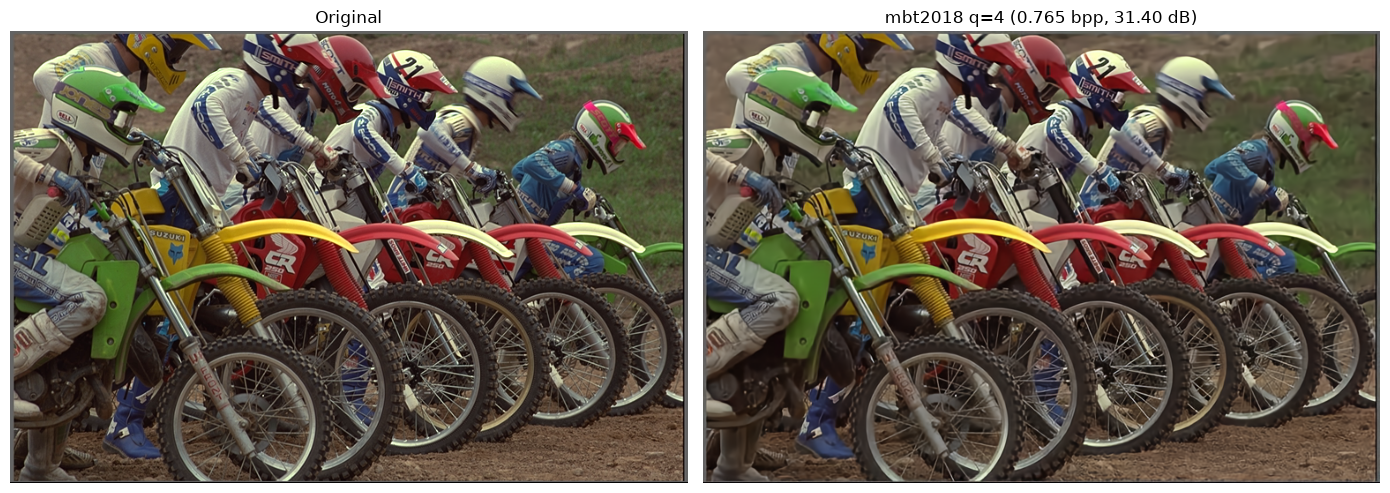

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(tensor_vers_image(img_tensor_batch)); axes[0].set_title("Original")
axes[1].imshow(image_mbt); axes[1].set_title(f"mbt2018 q=4 ({bpp_mbt:.3f} bpp, {psnr_mbt:.2f} dB)")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

### 2. Variation du paramètre q entre 1 et 8
Une même fonction évalue un modèle pour `q = 1 … 8` : elle sauvegarde chaque image reconstruite et renvoie les listes de débits et de PSNR (équivalent des variables `bpp11…bpp18`, `psnr11…psnr18` du polycopié, sans `globals()`).

In [8]:
def evaluer_modele(nom, constructeur, x, qualities=QUALITIES):
    bitrates, psnrs = [], []
    for q in qualities:
        model = constructeur(quality=q, pretrained=True).eval().to(device)
        rec, bpp, psnr, t_enc, t_dec = compresser_decompresser(model, x)

        tensor_vers_image(rec).save(os.path.join(OUT_DIR, f"testrec_{nom}_q{q}.png"))

        bitrates.append(bpp)
        psnrs.append(psnr)
        print(f"{nom} | q={q} -> Bitrate = {bpp:.4f} bpp - PSNR = {psnr:.2f} dB"
              f"  (enc {t_enc:.1f}s, dec {t_dec:.1f}s)")
    return bitrates, psnrs

#### 2.1 bmshj2018-factorized

In [9]:
bitrates1, psnr_values1 = evaluer_modele("bmshj2018-factorized", bmshj2018_factorized, img_tensor_batch)

Downloading: "https://compressai.s3.amazonaws.com/models/v1/bmshj2018-factorized-prior-1-446d5c7f.pth.tar" to /home/primaryos/.cache/torch/hub/checkpoints/bmshj2018-factorized-prior-1-446d5c7f.pth.tar
100%|██████████| 11.5M/11.5M [00:03<00:00, 3.37MB/s]


bmshj2018-factorized | q=1 -> Bitrate = 0.1873 bpp - PSNR = 23.54 dB  (enc 0.1s, dec 0.3s)


Downloading: "https://compressai.s3.amazonaws.com/models/v1/bmshj2018-factorized-prior-2-87279a02.pth.tar" to /home/primaryos/.cache/torch/hub/checkpoints/bmshj2018-factorized-prior-2-87279a02.pth.tar
100%|██████████| 11.5M/11.5M [00:03<00:00, 3.91MB/s]


bmshj2018-factorized | q=2 -> Bitrate = 0.2945 bpp - PSNR = 24.95 dB  (enc 0.4s, dec 0.5s)


Downloading: "https://compressai.s3.amazonaws.com/models/v1/bmshj2018-factorized-prior-3-5c6f152b.pth.tar" to /home/primaryos/.cache/torch/hub/checkpoints/bmshj2018-factorized-prior-3-5c6f152b.pth.tar
100%|██████████| 11.6M/11.6M [00:25<00:00, 484kB/s]


...

bmshj2018-factorized | q=6 -> Bitrate = 1.3681 bpp - PSNR = 33.65 dB  (enc 0.3s, dec 0.4s)


Downloading: "https://compressai.s3.amazonaws.com/models/v1/bmshj2018-factorized-prior-7-6dfd6734.pth.tar" to /home/primaryos/.cache/torch/hub/checkpoints/bmshj2018-factorized-prior-7-6dfd6734.pth.tar
100%|██████████| 27.5M/27.5M [00:44<00:00, 648kB/s] 


bmshj2018-factorized | q=7 -> Bitrate = 1.8299 bpp - PSNR = 35.90 dB  (enc 0.3s, dec 0.3s)


Downloading: "https://compressai.s3.amazonaws.com/models/v1/bmshj2018-factorized-prior-8-5232faa3.pth.tar" to /home/primaryos/.cache/torch/hub/checkpoints/bmshj2018-factorized-prior-8-5232faa3.pth.tar
100%|██████████| 27.9M/27.9M [00:10<00:00, 2.78MB/s]


bmshj2018-factorized | q=8 -> Bitrate = 2.3568 bpp - PSNR = 38.31 dB  (enc 0.4s, dec 0.4s)


#### 2.2 bmshj2018-hyperprior

In [10]:
bitrates2, psnr_values2 = evaluer_modele("bmshj2018-hyperprior", bmshj2018_hyperprior, img_tensor_batch)

Downloading: "https://compressai.s3.amazonaws.com/models/v1/bmshj2018-hyperprior-1-7eb97409.pth.tar" to /home/primaryos/.cache/torch/hub/checkpoints/bmshj2018-hyperprior-1-7eb97409.pth.tar
100%|██████████| 20.2M/20.2M [00:28<00:00, 730kB/s] 


bmshj2018-hyperprior | q=1 -> Bitrate = 0.2394 bpp - PSNR = 24.81 dB  (enc 0.3s, dec 0.3s)


Downloading: "https://compressai.s3.amazonaws.com/models/v1/bmshj2018-hyperprior-2-93677231.pth.tar" to /home/primaryos/.cache/torch/hub/checkpoints/bmshj2018-hyperprior-2-93677231.pth.tar
100%|██████████| 20.2M/20.2M [00:35<00:00, 590kB/s] 


bmshj2018-hyperprior | q=2 -> Bitrate = 0.3830 bpp - PSNR = 26.79 dB  (enc 0.4s, dec 0.2s)


Downloading: "https://compressai.s3.amazonaws.com/models/v1/bmshj2018-hyperprior-3-6d87be32.pth.tar" to /home/primaryos/.cache/torch/hub/checkpoints/bmshj2018-hyperprior-3-6d87be32.pth.tar
100%|██████████| 20.2M/20.2M [00:05<00:00, 4.02MB/s]


...

bmshj2018-hyperprior | q=6 -> Bitrate = 1.4434 bpp - PSNR = 35.37 dB  (enc 0.3s, dec 0.4s)


Downloading: "https://compressai.s3.amazonaws.com/models/v1/bmshj2018-hyperprior-7-3804dcbd.pth.tar" to /home/primaryos/.cache/torch/hub/checkpoints/bmshj2018-hyperprior-7-3804dcbd.pth.tar
100%|██████████| 46.0M/46.0M [00:16<00:00, 3.00MB/s]


bmshj2018-hyperprior | q=7 -> Bitrate = 1.8455 bpp - PSNR = 37.28 dB  (enc 0.3s, dec 0.4s)


Downloading: "https://compressai.s3.amazonaws.com/models/v1/bmshj2018-hyperprior-8-a583f0cf.pth.tar" to /home/primaryos/.cache/torch/hub/checkpoints/bmshj2018-hyperprior-8-a583f0cf.pth.tar
100%|██████████| 46.0M/46.0M [00:43<00:00, 1.11MB/s]


bmshj2018-hyperprior | q=8 -> Bitrate = 2.3216 bpp - PSNR = 39.49 dB  (enc 0.3s, dec 0.4s)


#### 2.3 mbt2018-mean

In [11]:
bitrates3, psnr_values3 = evaluer_modele("mbt2018-mean", mbt2018_mean, img_tensor_batch)

Downloading: "https://compressai.s3.amazonaws.com/models/v1/mbt2018-mean-1-e522738d.pth.tar" to /home/primaryos/.cache/torch/hub/checkpoints/mbt2018-mean-1-e522738d.pth.tar
100%|██████████| 27.6M/27.6M [00:07<00:00, 3.65MB/s]


mbt2018-mean | q=1 -> Bitrate = 0.2400 bpp - PSNR = 24.84 dB  (enc 0.3s, dec 0.3s)


Downloading: "https://compressai.s3.amazonaws.com/models/v1/mbt2018-mean-2-e54a039d.pth.tar" to /home/primaryos/.cache/torch/hub/checkpoints/mbt2018-mean-2-e54a039d.pth.tar
100%|██████████| 27.6M/27.6M [00:46<00:00, 626kB/s] 


mbt2018-mean | q=2 -> Bitrate = 0.3813 bpp - PSNR = 26.97 dB  (enc 0.2s, dec 0.2s)


Downloading: "https://compressai.s3.amazonaws.com/models/v1/mbt2018-mean-3-723404a8.pth.tar" to /home/primaryos/.cache/torch/hub/checkpoints/mbt2018-mean-3-723404a8.pth.tar
100%|██████████| 27.6M/27.6M [00:07<00:00, 3.80MB/s]


...

mbt2018-mean | q=6 -> Bitrate = 1.4414 bpp - PSNR = 35.67 dB  (enc 0.3s, dec 0.4s)


Downloading: "https://compressai.s3.amazonaws.com/models/v1/mbt2018-mean-7-d5d441d1.pth.tar" to /home/primaryos/.cache/torch/hub/checkpoints/mbt2018-mean-7-d5d441d1.pth.tar
100%|██████████| 67.9M/67.9M [00:56<00:00, 1.25MB/s]


mbt2018-mean | q=7 -> Bitrate = 1.8726 bpp - PSNR = 37.76 dB  (enc 0.3s, dec 0.3s)


Downloading: "https://compressai.s3.amazonaws.com/models/v1/mbt2018-mean-8-8089ae3e.pth.tar" to /home/primaryos/.cache/torch/hub/checkpoints/mbt2018-mean-8-8089ae3e.pth.tar
100%|██████████| 67.9M/67.9M [00:53<00:00, 1.32MB/s]


mbt2018-mean | q=8 -> Bitrate = 2.3466 bpp - PSNR = 39.76 dB  (enc 0.5s, dec 0.4s)


### 4.3 Courbes débit-PSNR

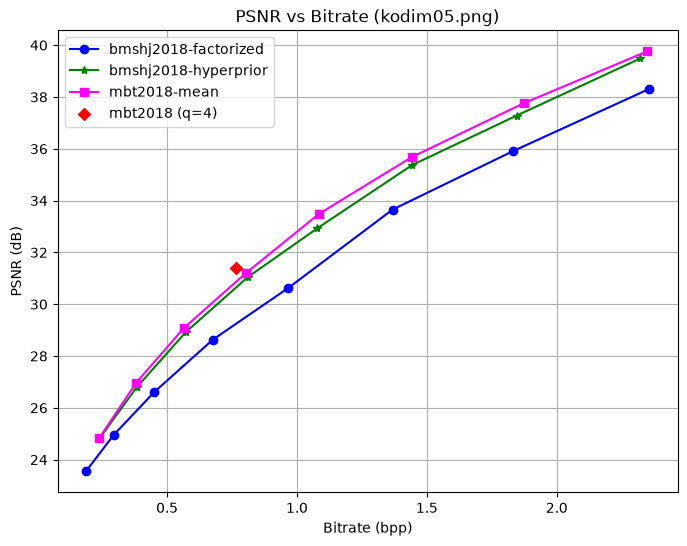

In [12]:
plt.figure(figsize=(8, 6))
plt.plot(bitrates1, psnr_values1, marker="o", linestyle="-", color="blue",    label="bmshj2018-factorized")
plt.plot(bitrates2, psnr_values2, marker="*", linestyle="-", color="green",   label="bmshj2018-hyperprior")
plt.plot(bitrates3, psnr_values3, marker="s", linestyle="-", color="magenta", label="mbt2018-mean")
plt.scatter([bpp_mbt], [psnr_mbt], marker="D", color="red", zorder=5, label="mbt2018 (q=4)")
plt.title(f"PSNR vs Bitrate ({IMAGE_NAME})")
plt.xlabel("Bitrate (bpp)")
plt.ylabel("PSNR (dB)")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(OUT_DIR, "bitrate_PSNR.png"), dpi=150)
plt.show()

### Tableau récapitulatif

In [13]:
print(f"{'q':>2} | {'factorized':>20} | {'hyperprior':>20} | {'mbt2018-mean':>20}")
print("   | " + " | ".join([f"{'bpp':>9} {'dB':>10}"] * 3))
print("-" * 76)
for i, q in enumerate(QUALITIES):
    cols = [f"{b[i]:9.4f} {p[i]:10.2f}"
            for b, p in ((bitrates1, psnr_values1), (bitrates2, psnr_values2), (bitrates3, psnr_values3))]
    print(f"{q:>2} | " + " | ".join(cols))

 q |           factorized |           hyperprior |         mbt2018-mean
   |       bpp         dB |       bpp         dB |       bpp         dB
----------------------------------------------------------------------------
 1 |    0.1873      23.54 |    0.2394      24.81 |    0.2400      24.84
 2 |    0.2945      24.95 |    0.3830      26.79 |    0.3813      26.97
 3 |    0.4509      26.61 |    0.5721      28.92 |    0.5653      29.09
 4 |    0.6764      28.63 |    0.8105      31.04 |    0.8037      31.20
 5 |    0.9652      30.62 |    1.0785      32.93 |    1.0855      33.49
 6 |    1.3681      33.65 |    1.4434      35.37 |    1.4414      35.67
 7 |    1.8299      35.90 |    1.8455      37.28 |    1.8726      37.76
 8 |    2.3568      38.31 |    2.3216      39.49 |    2.3466      39.76


### (Optionnel) Comparaison avec le codeur JPEG classique (TP1)

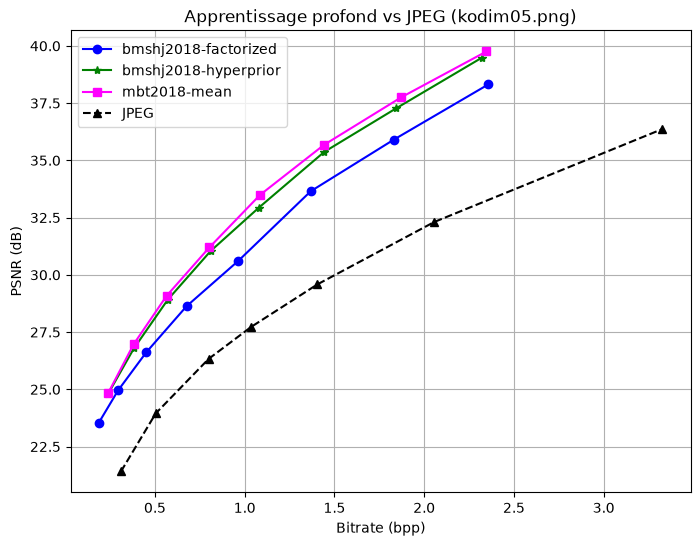

In [14]:
original = Image.open(os.path.join(DATA_DIR, IMAGE_NAME)).convert("RGB")
ref = torch.from_numpy(np.array(original)).permute(2, 0, 1).float().unsqueeze(0) / 255.0
num_pixels = original.size[0] * original.size[1]

br_jpg, ps_jpg = [], []
for q in [5, 10, 20, 30, 50, 75, 90]:
    p = os.path.join(OUT_DIR, f"jpeg_q{q}.jpg")
    original.save(p, "JPEG", quality=q)
    dec = torch.from_numpy(np.array(Image.open(p).convert("RGB"))).permute(2, 0, 1).float().unsqueeze(0) / 255.0
    br_jpg.append(os.path.getsize(p) * 8 / num_pixels)
    ps_jpg.append(psnr_torch(ref, dec))

plt.figure(figsize=(8, 6))
plt.plot(bitrates1, psnr_values1, marker="o", color="blue",    label="bmshj2018-factorized")
plt.plot(bitrates2, psnr_values2, marker="*", color="green",   label="bmshj2018-hyperprior")
plt.plot(bitrates3, psnr_values3, marker="s", color="magenta", label="mbt2018-mean")
plt.plot(br_jpg, ps_jpg, marker="^", linestyle="--", color="black", label="JPEG")
plt.title(f"Apprentissage profond vs JPEG ({IMAGE_NAME})")
plt.xlabel("Bitrate (bpp)")
plt.ylabel("PSNR (dB)")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(OUT_DIR, "bitrate_PSNR_vs_JPEG.png"), dpi=150)
plt.show()

## 3. Sauvegarder une image sous un autre format
On enregistre l'image reconstruite par `mbt2018` (q=4) dans plusieurs formats et on compare les tailles de fichier.

In [15]:
formats = {"png": "PNG", "tiff": "TIFF", "bmp": "BMP", "ppm": "PPM", "jpg": "JPEG", "webp": "WEBP"}

for ext, fmt in formats.items():
    chemin = os.path.join(OUT_DIR, f"reconstructed_image_r.{ext}")
    image_mbt.save(chemin, fmt)
    print(f"{ext:5s} -> {os.path.getsize(chemin) / 1024:9.1f} Ko")

# Conversion d'un fichier JPG existant vers un autre format
jpg = Image.open(os.path.join(OUT_DIR, "jpeg_q75.jpg"))
jpg.save(os.path.join(OUT_DIR, "jpeg_q75_converti.png"), "PNG")
jpg.save(os.path.join(OUT_DIR, "jpeg_q75_converti.tiff"), "TIFF")
print("Conversions JPG -> PNG / TIFF effectuées.")

png   ->     701.4 Ko
tiff  ->    1152.1 Ko
bmp   ->    1152.1 Ko
ppm   ->    1152.0 Ko
jpg   ->      89.2 Ko
webp  ->      77.7 Ko
Conversions JPG -> PNG / TIFF effectuées.
